In [19]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [20]:
#Loading the dataset
df = pd.read_csv('/content/dirty_cafe_sales.csv')

In [21]:
#preview
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [22]:
#understanding the shape
df.shape

(10000, 8)

### 10000rows  and 8 colums


In [23]:
#columns
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [24]:
#understanding dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [25]:
#summary stats
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Data Audit

In [26]:
#checking for missing values
df.isnull().sum().sum()

np.int64(6826)

In [27]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [28]:
#take a sample
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9940,TXN_8273780,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-10-15
9467,TXN_3787234,Tea,2,1.5,3.0,Digital Wallet,In-store,2023-03-15
3442,TXN_2363378,Coffee,5,2.0,10.0,Cash,Takeaway,2023-04-23
7201,TXN_8953489,Juice,5,3.0,15.0,NaN,In-store,NaN
1503,TXN_3455702,Salad,1,5.0,5.0,Cash,Takeaway,2023-03-23
7306,TXN_6234882,Cookie,4,1.0,4.0,Credit Card,ERROR,2023-01-01
6935,TXN_5005793,Sandwich,4,4.0,16.0,Credit Card,In-store,2023-01-21
3340,TXN_6179169,Sandwich,2,4.0,8.0,Cash,In-store,2023-10-21
8108,TXN_2019127,Salad,1,5.0,5.0,Cash,NaN,2023-08-03
5633,TXN_9323215,Cookie,3,1.0,3.0,NaN,NaN,2023-01-27


# Data Cleaning
1.hidden errors 'unknown','error'

2.incorrect data type

3.missing values


In [29]:
# remove error and unknown strings from our dataframe
invalid_values = ["ERROR", "UNKNOWN", "N/A"]

In [30]:
#Replace the invalid values with nan values
df.replace(invalid_values, np.nan, inplace = True)

In [31]:
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [32]:
#recheck for missing values
df.isnull().sum()

,0
Transaction ID,0
Item,969
Quantity,479
Price Per Unit,533
Total Spent,502
Payment Method,3178
Location,3961
Transaction Date,460


In [33]:
#fix datatypes
df['Quantity'] = pd.to_numeric(df['Quantity'],errors = 'coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'],errors = 'coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'],errors = 'coerce')


In [34]:
#convert transaction date to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')


In [35]:
#clean the text data
df['Item'] = df['Item'].str.strip().str.title()
df['Payment Method'] = df['Payment Method'].str.strip().str.title()

In [36]:
#fill missing numeric vaalues
df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'].fillna(df['Total Spent'].median())


,Total Spent
0,4.0
1,12.0
2,8.0
3,10.0
4,4.0
...,...
9995,4.0
9996,3.0
9997,8.0
9998,3.0


In [37]:
#recheck missing values
df.isnull().sum()

,0
Transaction ID,0
Item,969
Quantity,479
Price Per Unit,533
Total Spent,502
Payment Method,3178
Location,3961
Transaction Date,460


In [38]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [39]:
#fill categorical columns
df['Location'] = df['Location'].fillna("unknown")

In [40]:
df.shape

(10000, 8)

In [41]:
#Drop missing values
df.dropna(inplace=True)

In [42]:
#Recheck for missing values
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [43]:
df.shape

(5059, 8)

In [44]:
#exporting cleaned data to a csv file you can open in excel
df.to_csv('cleaned_cafe_sales.csv', index=False)

# Exploratory Data Analysis(EDA)

In [45]:
#Overall sales summary
print('Total sales: ', df['Total Spent'].sum())
print('Average sales: ', df['Total Spent'].mean())
print('Max sales: ', df['Total Spent'].max())
df['Total Spent'].sum()

Total sales:  45473.0
Average sales:  8.988535283652896
Max sales:  25.0


np.float64(45473.0)

In [46]:
#Sales by Item(Cafe Item)
df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

,Total Spent
Item,
Salad,10090.0
Smoothie,7508.0
Sandwich,7488.0
Juice,6105.0
Cake,5997.0
Coffee,3758.0
Tea,2709.0
Cookie,1818.0


In [47]:
#Sales trend by date and item
daily_sales = df.groupby(['Transaction Date', 'Item'])['Total Spent'].sum()
daily_sales.head()

Transaction Date  Item  
2023-01-01        Cake      21.0
                  Coffee    22.0
                  Cookie     4.0
                  Juice     18.0
                  Salad     10.0
Name: Total Spent, dtype: float64

In [48]:
# payment method breakdown
df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending = False)

,Total Spent
Payment Method,
Cash,15204.0
Digital Wallet,15172.5
Credit Card,15096.5


In [49]:
# top 5 products
df.groupby('Item')['Total Spent'].sum().sort_values(ascending= False).head(5)

,Total Spent
Item,
Salad,10090.0
Smoothie,7508.0
Sandwich,7488.0
Juice,6105.0
Cake,5997.0


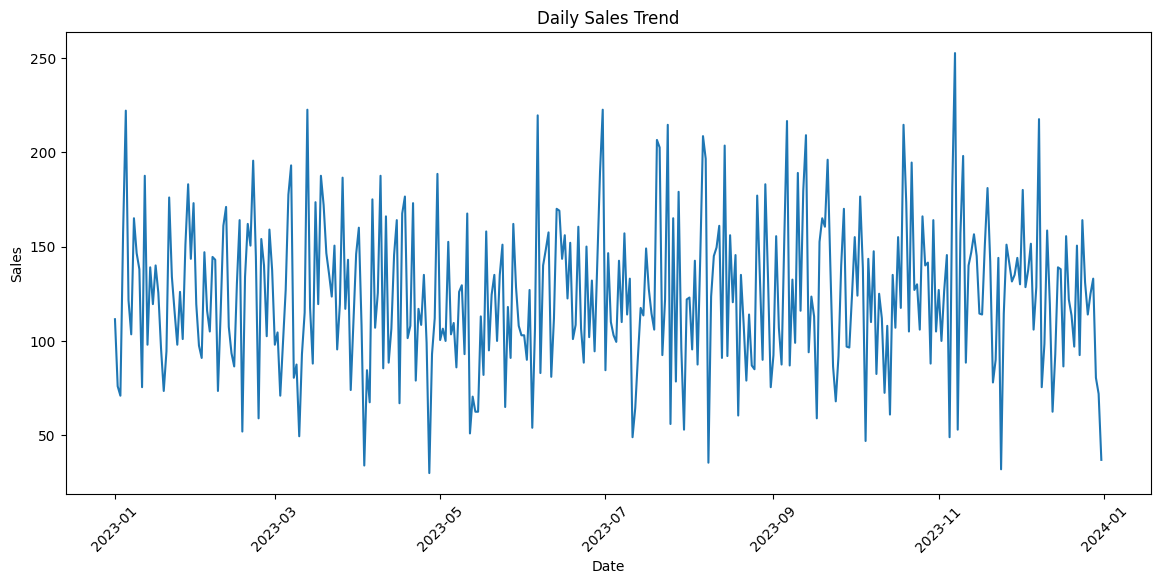

In [50]:
# sales over time
daily_sales= df.groupby('Transaction Date')['Total Spent'].sum()
#daily.sales.index is just transaction date
plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.show()

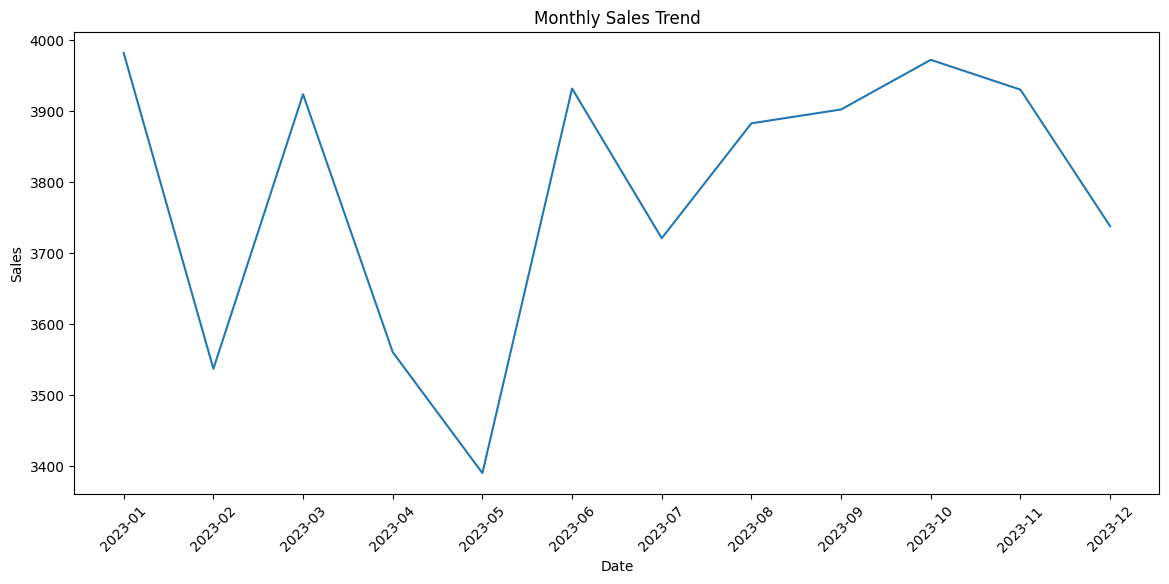

In [55]:
# sales over time
monthly_sales= df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum()
#daily.sales.index is just transaction date

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.show()

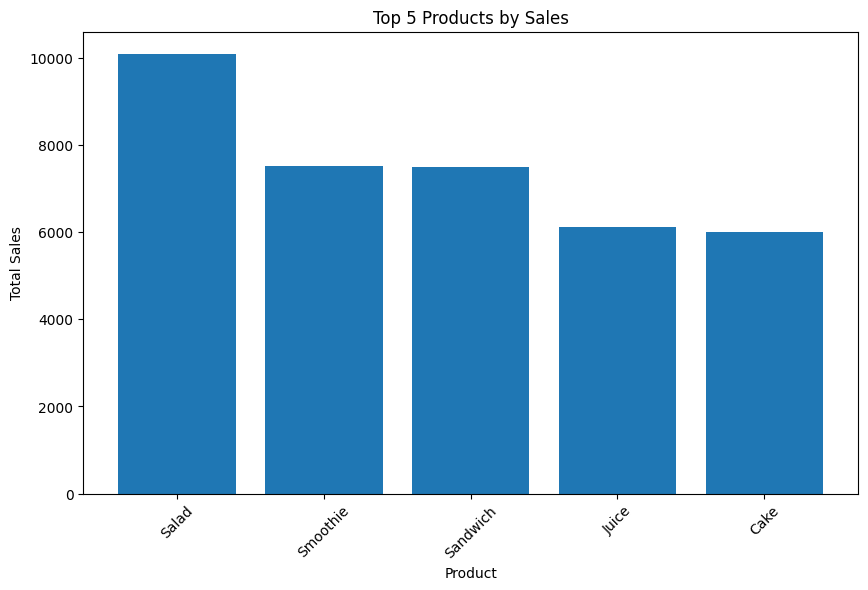

In [56]:
#Top products by sales
top_products = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,6))

plt.bar(top_products.index, top_products.values)
plt.title('Top 5 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()


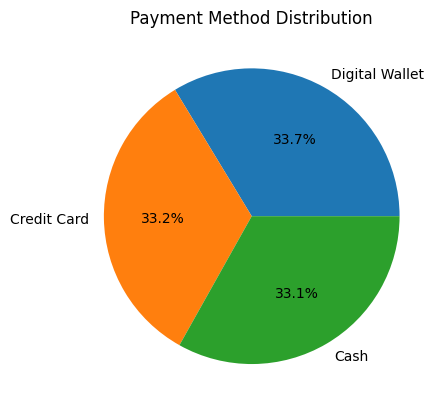

In [57]:
#payment method distribution
payment_counts = df['Payment Method'].value_counts()

plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()